In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Superstore.csv', encoding='latin1')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
sales_df = df[['Order Date', 'Sales']]

In [13]:
sales_df.head()

,Order Date,Sales
0,11/8/2016,261.9600
1,11/8/2016,731.9400
2,6/12/2016,14.6200
3,10/11/2015,957.5775
4,10/11/2015,22.3680


In [14]:
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])

In [15]:
sales_df.head()

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2016-06-12,14.6200
3,2015-10-11,957.5775
4,2015-10-11,22.3680


In [16]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9994 non-null   datetime64[ns]
 1   Sales       9994 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 156.3 KB


In [17]:
sales_df = sales_df.sort_values('Order Date')

In [18]:
sales_df = sales_df.groupby('Order Date')['Sales'].sum().reset_index()

In [19]:
sales_df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


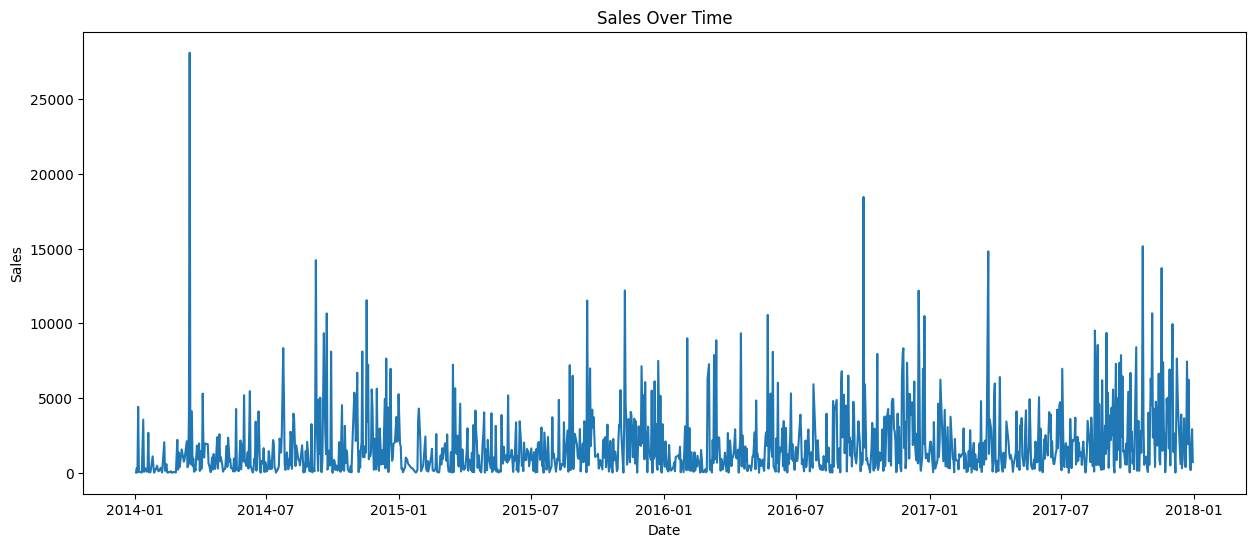

In [20]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x='Order Date',
    y='Sales',
    data=sales_df
)

plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [21]:
sales_df['Month'] = sales_df['Order Date'].dt.month

In [22]:
sales_df.head()

,Order Date,Sales,Month
0,2014-01-03,16.448,1
1,2014-01-04,288.060,1
2,2014-01-05,19.536,1
3,2014-01-06,4407.100,1
4,2014-01-07,87.158,1


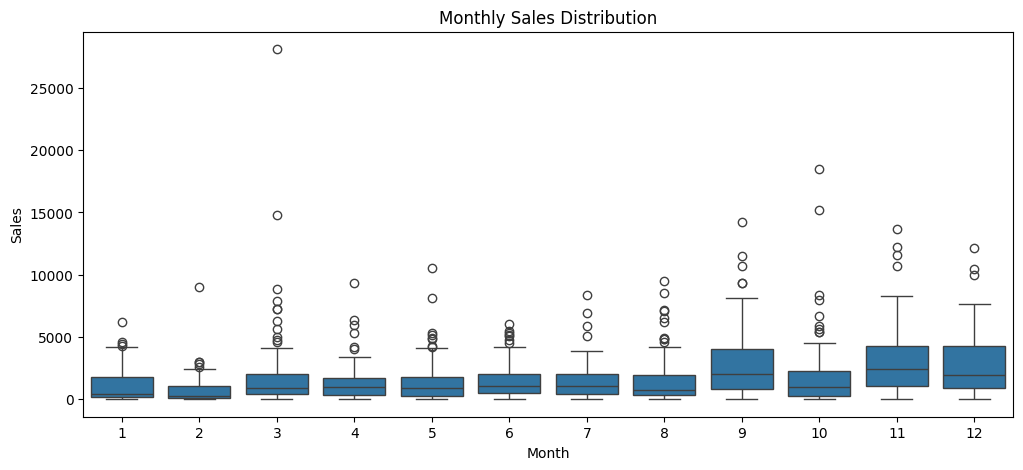

In [23]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x='Month',
    y='Sales',
    data=sales_df
)

plt.title('Monthly Sales Distribution')

plt.show()

In [24]:
sales_df['Year'] = sales_df['Order Date'].dt.year
sales_df['Month'] = sales_df['Order Date'].dt.month
sales_df['Day'] = sales_df['Order Date'].dt.day
sales_df['DayOfWeek'] = sales_df['Order Date'].dt.dayofweek
sales_df['Quarter'] = sales_df['Order Date'].dt.quarter

In [25]:
sales_df.head()

,Order Date,Sales,Month,Year,Day,DayOfWeek,Quarter
0,2014-01-03,16.448,1,2014,3,4,1
1,2014-01-04,288.060,1,2014,4,5,1
2,2014-01-05,19.536,1,2014,5,6,1
3,2014-01-06,4407.100,1,2014,6,0,1
4,2014-01-07,87.158,1,2014,7,1,1


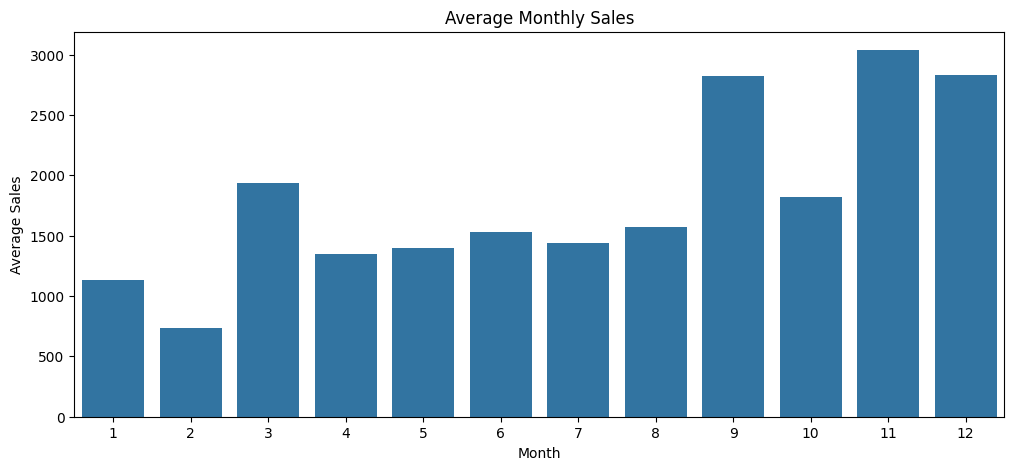

In [26]:
plt.figure(figsize=(12,5))

monthly_sales = sales_df.groupby('Month')['Sales'].mean()

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.show()

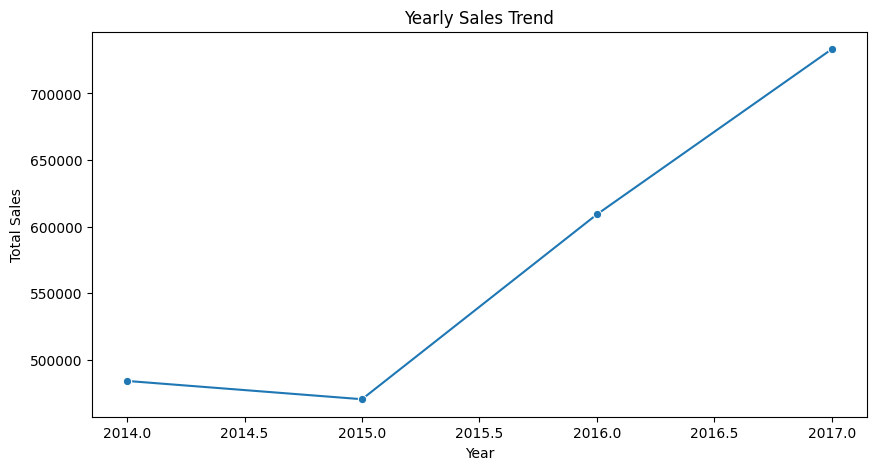

In [27]:
plt.figure(figsize=(10,5))

yearly_sales = sales_df.groupby('Year')['Sales'].sum()

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker='o'
)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.show()

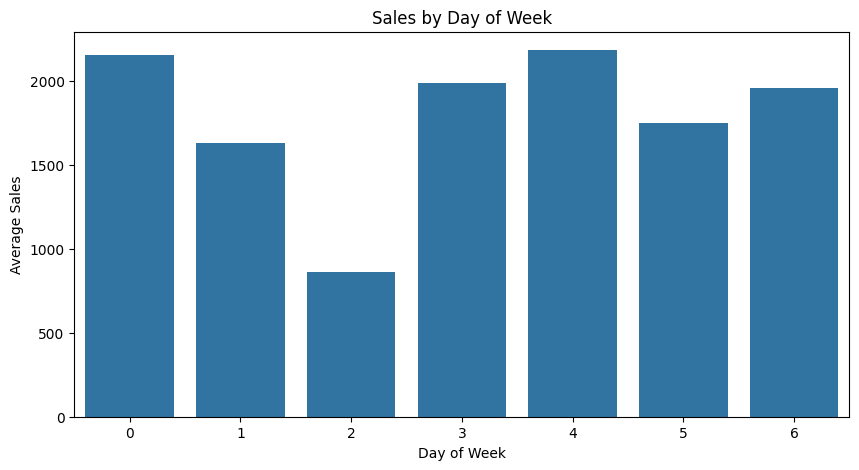

In [28]:
plt.figure(figsize=(10,5))

dow_sales = sales_df.groupby('DayOfWeek')['Sales'].mean()

sns.barplot(
    x=dow_sales.index,
    y=dow_sales.values
)

plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')

plt.show()

In [35]:
prophet_df = sales_df[['Order Date', 'Sales']]

In [36]:
prophet_df.columns = ['ds', 'y']

In [31]:
prophet_df.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [37]:
from prophet import Prophet
from prophet.make_holidays import make_holidays_df

In [38]:
us_holidays = make_holidays_df(
    year_list=[2023, 2024, 2025, 2026],
    country='US'
)

In [39]:
us_holidays.head()

,ds,holiday
0,2024-01-01,New Year's Day
1,2024-05-27,Memorial Day
2,2024-06-19,Juneteenth National Independence Day
3,2024-07-04,Independence Day
4,2024-09-02,Labor Day


In [40]:
model = Prophet(
    holidays=us_holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [41]:
model.fit(prophet_df)

In [42]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [43]:
future.tail()

,ds
1322,2018-03-26
1323,2018-03-27
1324,2018-03-28
1325,2018-03-29
1326,2018-03-30


In [44]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Columbus Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1322,2018-03-26,2376.172491,119.353160,5786.503936,2373.080388,2378.683589,0.0,0.0,0.0,0.0,...,411.594227,411.594227,411.594227,222.573598,222.573598,222.573598,0.0,0.0,0.0,3010.340317
1323,2018-03-27,2377.165157,-401.620022,5039.505117,2374.014593,2379.714603,0.0,0.0,0.0,0.0,...,-172.031231,-172.031231,-172.031231,157.244211,157.244211,157.244211,0.0,0.0,0.0,2362.378138
1324,2018-03-28,2378.157824,-1159.384180,4270.104094,2374.958678,2380.747223,0.0,0.0,0.0,0.0,...,-1040.398433,-1040.398433,-1040.398433,91.546301,91.546301,91.546301,0.0,0.0,0.0,1429.305692
1325,2018-03-29,2379.150490,-105.580439,5265.601379,2375.895854,2381.808283,0.0,0.0,0.0,0.0,...,155.962630,155.962630,155.962630,26.704446,26.704446,26.704446,0.0,0.0,0.0,2561.817565
1326,2018-03-30,2380.143156,10.717880,5455.617853,2376.784232,2382.870582,0.0,0.0,0.0,0.0,...,419.702891,419.702891,419.702891,-36.157525,-36.157525,-36.157525,0.0,0.0,0.0,2763.688522


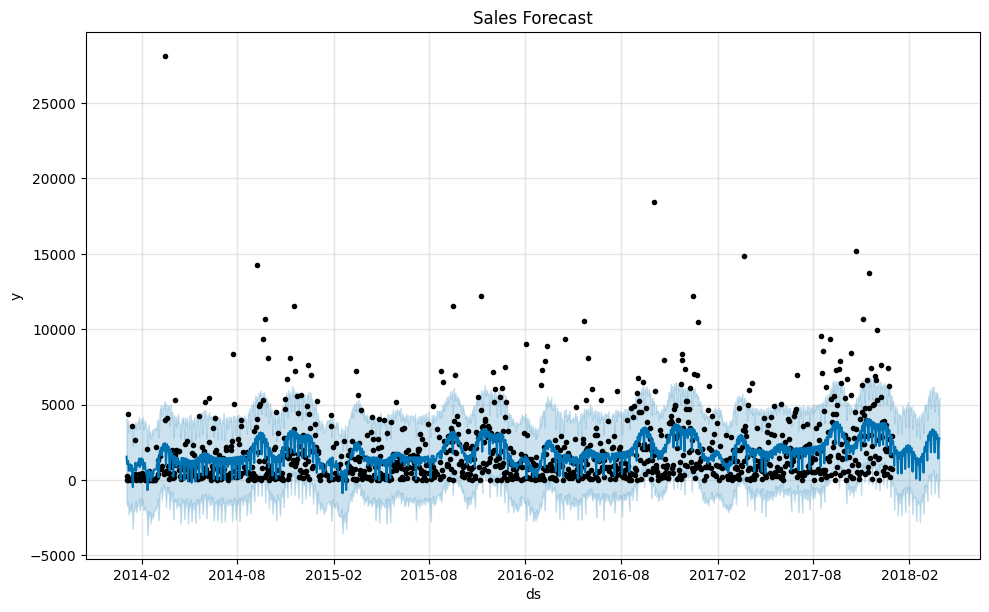

In [45]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

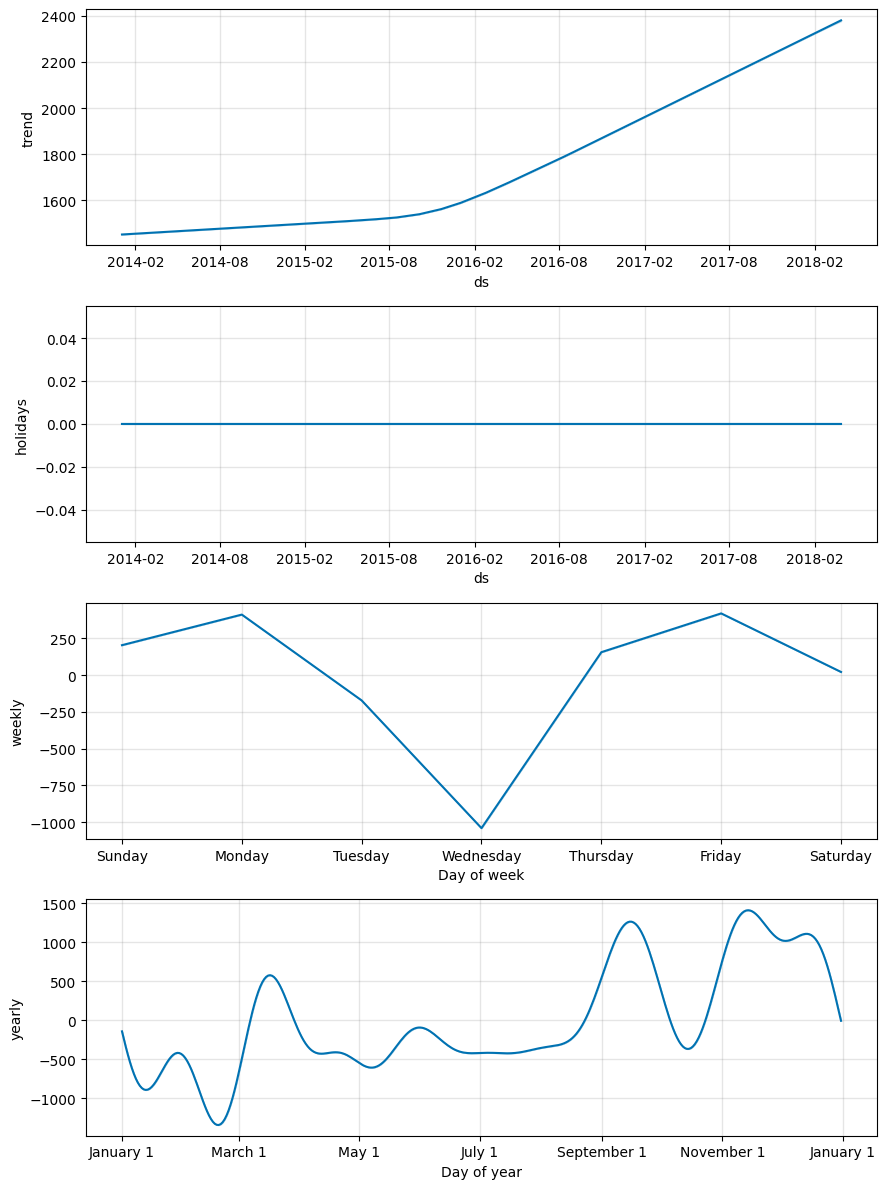

In [46]:
fig2 = model.plot_components(forecast)
plt.show()

In [47]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(15)

,ds,yhat,yhat_lower,yhat_upper
1312,2018-03-16,3356.153133,458.483341,6187.407942
1313,2018-03-17,2966.563978,242.257347,5688.171122
1314,2018-03-18,3145.450122,520.648908,5807.249347
1315,2018-03-19,3338.964035,654.272508,6174.028099
1316,2018-03-20,2730.524828,-161.722678,5316.082879
1317,2018-03-21,1827.947483,-895.479507,4538.345458
1318,2018-03-22,2981.823506,257.845653,5507.313756
1319,2018-03-23,3196.034032,168.125040,5832.258504
1320,2018-03-24,2742.588107,-46.649072,5453.981483
1321,2018-03-25,2865.060148,413.171285,5720.371431


In [48]:
forecast.to_csv('sales_forecast.csv', index=False)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge actuals with forecast to evaluate historical predictions
performance_df = pd.merge(prophet_df, forecast[['ds', 'yhat']], on='ds', how='inner')

# Calculate evaluation metrics
mae = mean_absolute_error(performance_df['y'], performance_df['yhat'])
mse = mean_squared_error(performance_df['y'], performance_df['yhat'])
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 1402.91
Mean Squared Error (MSE): 4564386.85
Root Mean Squared Error (RMSE): 2136.44


In [51]:
import pickle

# Save the Prophet model
with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Prophet model saved as 'prophet_model.pkl'")

Prophet model saved as 'prophet_model.pkl'
